In [40]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import synthpop
import pdb
import time

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [11]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle_multiples', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name": "BinaryCompanions"}, {"name":"ProcessDarkCompactObjects", "remove":False, "ifmr_name":'SukhboldN20',
                                                     "kick_mean_ns":350, "kick_mean_bh":100}, # IFMR + kick velocities
                                {"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"} #{"name":"surot"}
                          )
sp_mod.init_populations()



################################ Settings #################################
 992807 - # reading default parameters from
 992810 - default_config_file =  /u/shepbrooke/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 992819 - # read configuration from 
 992822 - config_file = '/u/shepbrooke/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 992825 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "synthpopsycle_multiples",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 7958648,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,
        "w_lsr": 0.53
    

Then, run the specific sightline you want

In [13]:
t0=time.time()
_ = sp_mod.process_location(1, -1.2, # first, enter l and b in degrees
                            solid_angle=1e-4, solid_angle_unit='deg^2', # solid angle can be in deg^2 or sr
                            save_data=False) # this prevents synthpop from saving in its default format, it will already be saved via popsycle_post_processing
print(f'Synthpop catalog generated in {np.round((time.time()-t0)/60, 2)} minutes.')

/u/shepbrooke/code/synthpop/synthpop/synthpop_utils/synthpop_logging.py:160: ResourceWarning: unclosed file <_io.TextIOWrapper name='/var/folders/wk/sfy67zx52qd6kyw13xvt_h0800013t/T/tmp72kkueeu' mode='a' encoding='UTF-8'>
  self.filelogger = logging.FileHandler(filename)


############################# update location #############################
 1108827 - # set location to: 
 1108830 - l, b = (1.00 deg, -1.20 deg)
 1108832 - # set solid_angle to:
 1108835 - solid_angle = 1.000e-04 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 1112019 - # From density profile (number density)
 1112022 - expected_total_iMass = 40400.4587
 1112024 - expected_total_eMass = 22043.2167
 1112026 - average_iMass_per_star = 0.5739
 1112028 - mass_loss_correction = 0.5456
 1112030 - n_expected_stars = 70400.5151
 1112035 - # Determine velocities when position are generated 
 1114015 - # From Ge


Running binary post processing

+++++++++++++++++++
1.1709752112612914
True
1.0879241076927892
True
1.1179544166649733
True
1.1086370990416368
True
1.3015158106272064
True
1.1023495255762312
True
1.1340194818687892
True
1.1790481141374152
True
1.111116375153894
True
1.3217484377160758
True
1.0229696992919757
True
1.0904299885393827
True
1.0356325249419742
True
1.0528639794515302
True
1.0644425672760227
True
1.2657082113050817
True
1.3127283770325284
True
1.065214614219913
True
1.0527908471399303
True
1.2530655223663714
True
1.0361882017898723
True
1.079829032461586
True
1.0921068144445263
True
1.0836439131630813
True
1.1989617366733476
True
1.0122846043541585
True
1.099107896444733
True
1.038654760881491
True
1.245418403094734
True
1.2002632294902544
True
1.026111670908221
True
1.0597808717832649
True
1.0557899794342318
True
1.1426406927440431
True
1.1887426197843067
True
1.0725056093169527
True
1.1661159332307334
True
1.0033553683097396
True
1.1931089085770912
True
1.0331882684399611

 1183905 - Beginning compact object postprocessing.
 1183929 - Compact object postprocessing complete.
 1183931 - Beginning PopSyCLE postprocessing.
 1183947 - E(B-V) calculated
 1183953 - Parameter file written
 1183955 - Basic columns renamed
 1183962 - Age units converted
 1183970 - Galactic longitude wrapped
 1183975 - Added mbol via eval
 1183978 - Added systemMass via eval
 1183981 - Renamed mag cols
 1183998 - Multiplicity and remnant columns added


PopSyCLE formatted companions output saved in synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_companions.h5


 1185790 - Binary file generated.
 1185800 - Unused columns dropped
 1185807 - PopSyCLE dataframe modifications complete - binning and saving file


Index(['popid', 'zams_mass', 'age', 'Fe/H_initial', 'mass', 'In_Final_Phase',
       'rad', 'glon', 'glat', 'vr', 'mu_lcosb', 'mu_b', 'px', 'py', 'pz', 'vx',
       'vy', 'vz', 'VR_LSR', 'log_L', 'teff', 'grav', 'feh', 'log_R', 'ubv_U',
       'ubv_B', 'ubv_V', 'ubv_R', 'ubv_I', '2MASS_J', '2MASS_H', '2MASS_Ks',
       'ID', 'isMultiple', 'primary_ID', 'binary_frac', 'combined_logL',
       'total_mass', 'q', 'logP', 'exbv', 'mbol', 'systemMass', 'rem_id',
       'obj_id', 'N_companions', 'system_idx', 'zams_mass_prim'],
      dtype='object')
Index(['popid', 'zams_mass', 'age', 'mass', 'rad', 'glon', 'glat', 'vr',
       'mu_lcosb', 'mu_b', 'px', 'py', 'pz', 'vx', 'vy', 'vz', 'log_L', 'teff',
       'grav', 'feh', 'ubv_U', 'ubv_B', 'ubv_V', 'ubv_R', 'ubv_I',
       'isMultiple', 'exbv', 'mbol', 'systemMass', 'rem_id', 'obj_id',
       'N_companions'],
      dtype='object')
Index(['popid', 'zams_mass', 'age', 'mass', 'rad', 'glon', 'glat', 'vr',
       'mu_lcosb', 'mu_b', 'px', 'py', 'p

 1186313 - PopSyCLE formatted output saved in synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc.h5
 1189457 - ---------------------------------------------------------------



Synthpop catalog generated in 1.34 minutes.


# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [14]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc.h5", 
                      hdf5_file_comp = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_companions.h5", 
                      output_root2 = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc",  
                      radius_cut = 2, obs_time = 1000,  n_obs = 11,  
                      theta_frac = 2,  blend_rad = 0.65,  overwrite = True,  n_proc = 4)

Working on loop ll, bb =  0 0
Candidate events detected:  9400
calc_events runtime : 303.142032 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [15]:
synthetic.refine_events(input_root = 'synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc',
                        hdf5_file_comp = 'synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_companions.h5',
                        filter_dict={'ubv':['I']},
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  7326
Candidate events in survey window:  959
On square l0b0
On square l0b1
On square l1b0
On square l1b1
refine_events runtime : 147.402818 s


In [16]:
synthetic.refine_binary_events(events="synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16.fits", 
                               companions = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_companions.fits", 
                               filter_name = 'I',
                               photometric_system = 'ubv', 
                               overwrite = True,
                               n_proc=1,
                               output_file = 'default', 
                               save_phot = True, 
                               phot_dir = 'example_bin_phot')

/u/shepbrooke/code/PopSyCLE/popsycle/synthetic.py:5478: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_table_df['companion_idx_list'].loc[obj_id_L_S] = list(grouped_comps.groups[i]['companion_idx'])
/opt/mambaforge3/envs/astro-synthpop/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "epv00" yielded 5000 of "warning: date outsidethe range 1900-2100 AD"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/u/shepbrooke/code/BAGLE_Microlensing/src/bagle/model.py:2239: UserWarning: Warning: converting a masked element to nan.
  setattr(self, param, np.array(param_var))
/opt/mambaforge3/envs/astro-synthpop/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "epv00" yielded 5000 of "warning: date outsidethe range 1900-2100 AD"
  warning

refine_binary_events runtime : 245.475008 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [29]:
t = Table.read('synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_rb.fits')
print(t.colnames)

bin = Table.read('synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_companions_rb.fits')
print(bin.colnames)

['obj_id_L', 'obj_id_S', 'popid_L', 'zams_mass_L', 'age_L', 'mass_L', 'rad_L', 'glon_L', 'glat_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'log_L_L', 'teff_L', 'grav_L', 'feh_L', 'ubv_U_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'ubv_I_L', 'isMultiple_L', 'exbv_L', 'mbol_L', 'systemMass_L', 'rem_id_L', 'N_companions_L', 'sep_L', 'popid_S', 'zams_mass_S', 'age_S', 'mass_S', 'rad_S', 'glon_S', 'glat_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'log_L_S', 'teff_S', 'grav_S', 'feh_S', 'ubv_U_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'ubv_I_S', 'isMultiple_S', 'exbv_S', 'mbol_S', 'systemMass_S', 'rem_id_S', 'N_companions_S', 'sep_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed', 'n_peaks', 'bin_delta_m', 'tE_sys', 'tE_primary', 'primary_t', 'avg_t', 'std_t', 'asymmetry

## Figure out how many events due to BH, NS, WD, star

In [18]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 11
Number of NSs: 24
Number of WDs: 126
Number of stars: 798


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

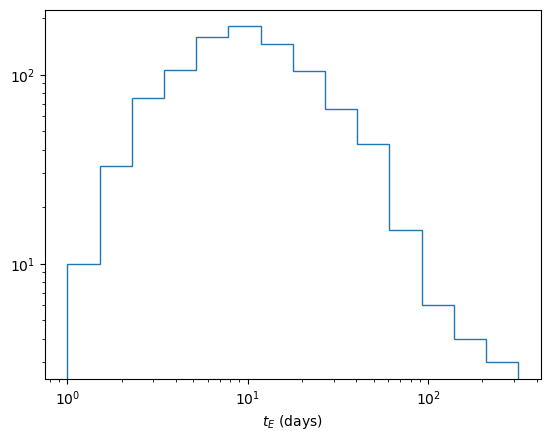

In [26]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

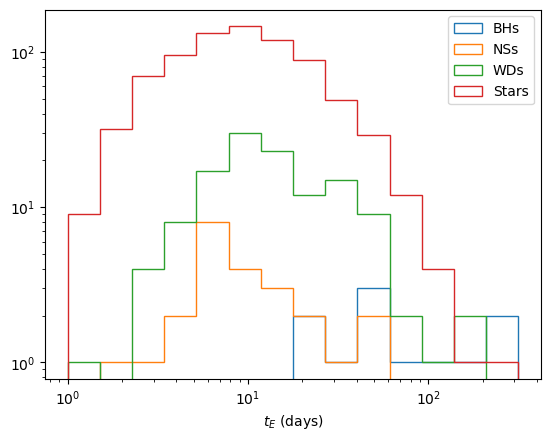

In [33]:
bh_idx = t[t['rem_id_L'] == 103]
ns_idx = t[t['rem_id_L'] == 102]
wd_idx = t[t['rem_id_L'] == 101]
st_idx = t[t['rem_id_L'] == 0]

plt.hist(bh_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="BHs")
plt.hist(ns_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="NSs")
plt.hist(wd_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="WDs")
plt.hist(st_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Stars")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

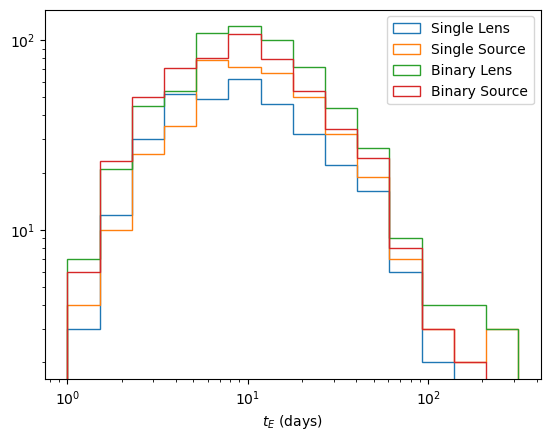

In [34]:
no_companions_lens = t[t['N_companions_L'] == 0]
no_companions_source = t[t['N_companions_S'] == 0]
companions_lens = t[t['N_companions_L'] != 0]
companions_source= t[t['N_companions_S'] != 0]

plt.hist(no_companions_lens['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single Lens")
plt.hist(no_companions_source['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single Source")
plt.hist(companions_lens['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary Lens")
plt.hist(companions_source['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary Source")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

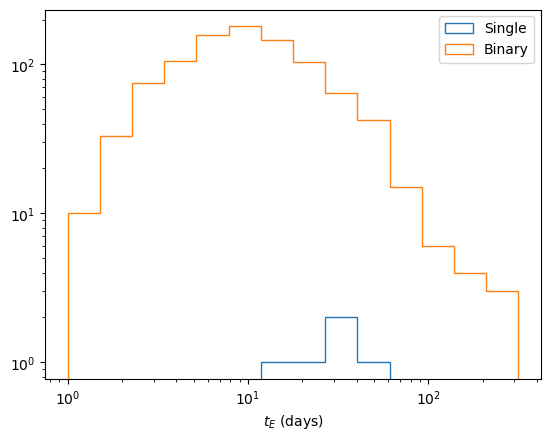

In [42]:
single = no_companions_lens[no_companions_lens['N_companions_S'] == 0]
plbs = no_companions_lens[no_companions_lens['N_companions_S'] != 0]
blps = no_companions_source[no_companions_source['N_companions_L'] != 0]
blbs = companions_source[companions_source['N_companions_L'] != 0]

binary = vstack([plbs, blps, blbs])

plt.hist(single['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single")
plt.hist(binary['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

## piE vs tE

<>:8: DeprecationWarning: invalid escape sequence '\p'


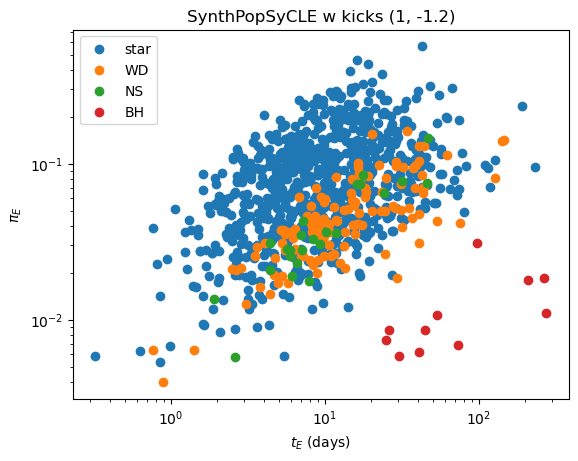

In [20]:
lens_type={0:'star', 101:'WD', 102:'NS', 103:'BH'}
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label=lens_type[rem_id])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend(loc=2)
plt.title('SynthPopSyCLE w kicks (1, -1.2)')
plt.savefig('synthpopsycle_lenstype_multiples.png')

## dL vs dS

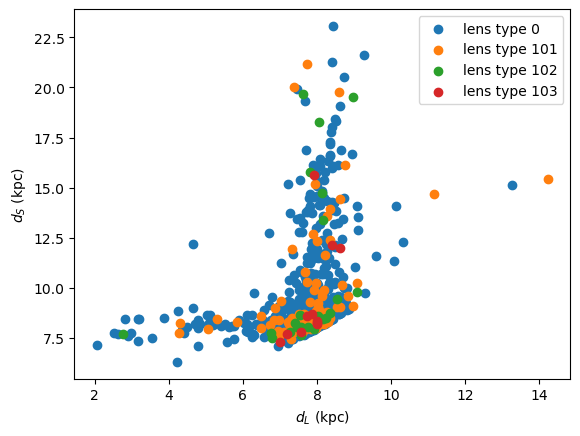

In [21]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()